In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [ ]:
# put raw data here, in paired order

allocate_counts = [66, 21, 60, 63, 31, 40, 60, 71, 45, 106]
pathologist_counts = [55, 20, 60, 60, 25, 36, 54, 58, 41, 89]

In [61]:
x = np.array(allocate_counts, dtype=int)
y = np.array(pathologist_counts, dtype=int)

if len(x) != len(y):
    raise ValueError("Both lists must have the same length.")

In [ ]:
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

r_squared = r2_score(y, y_pred)

print("Slope:", slope)
print("Intercept:", intercept)
print("R^2:", r_squared)

Slope: 0.8270688412150974
Intercept: 3.236024239590026
R^2: 0.9677407661874521


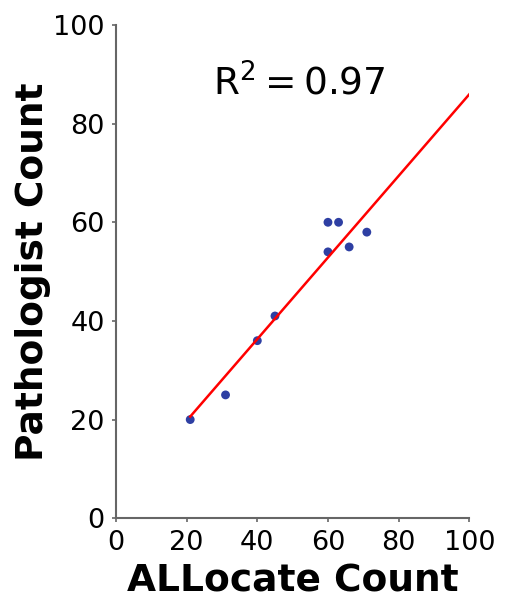

In [63]:
fig, ax = plt.subplots(figsize=(3.5, 4.2), dpi=150)

# Scatter points
ax.scatter(x, y, s=18, color="#2E3FA3", edgecolors="none")

# Solid fit line across data range
x_line_solid = np.linspace(x.min(), x.max(), 200)
y_line_solid = slope * x_line_solid + intercept
ax.plot(x_line_solid, y_line_solid, color="red", linewidth=1.2)

# Dashed extension
x_line_dash = np.linspace(x.max(), max(x.max(), y.max()) * 1.05, 100)
y_line_dash = slope * x_line_dash + intercept
ax.plot(x_line_dash, y_line_dash, color="red", linewidth=1.2, linestyle="--")

# R^2 text
ax.text(
    0.52, 0.92,
    rf"$\mathrm{{R}}^2 = {r_squared:.2f}$",
    transform=ax.transAxes,
    ha="center", va="top",
    fontsize=18,
    fontweight="bold"
)

# Labels
ax.set_xlabel("ALLocate Count", fontsize=18, fontweight="bold")
ax.set_ylabel("Pathologist Count", fontsize=18, fontweight="bold", labelpad=1)

# Axis styling
ax.tick_params(axis="both", labelsize=13, width=0.8, length=2, color="#666666")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")

ax.grid(False)

ax.set_xticks(np.arange(0, 121, 20))
ax.set_yticks(np.arange(0, 121, 20))
ax.set_xlim(0, 100)
ax.set_ylim(0,100)
plt.tight_layout()
plt.show()

In [ ]:
save_name = "fig5_e_allocate_vs_pathologist_r2.png"
fig.savefig(save_name, dpi=300, bbox_inches="tight")
print(f"Saved {save_name}")